Hello , *Hoshang this side and this is my first ml model implementation*

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

In [5]:
data=pd.read_csv('house_prices.csv')


In [6]:
data.head()

,size_sqft,price
0,519.3,91624.62
1,572.0,106064.35
2,589.0,87749.07
3,620.4,115302.68
4,658.3,55332.05


"Initialize variables" -extract features,targets and no. of training examples

In [7]:
X=data['size_sqft'].to_numpy()
Y=data['price'].to_numpy()
m=X.shape[0]

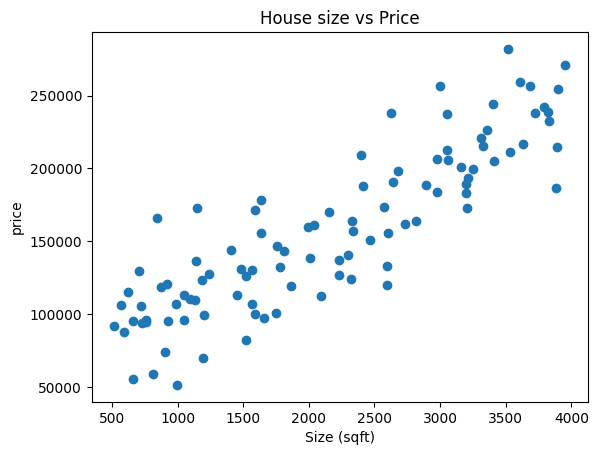

In [8]:
plt.scatter(X,Y)
plt.xlabel('Size (sqft)')
plt.ylabel('price')
plt.title('House size vs Price')
plt.show()

In [9]:
def computecost(X,Y,w,b,m):
    cost=0
    for i in range(m):
        f_wb=w*X[i]+b
        cost=cost+(f_wb-Y[i])**2
    total_cost=(1/(2*m))*cost
    return total_cost
        
    

In [10]:
computecost(X,Y,0,0,m)

np.float64(13865074181.775997)

In [11]:
def calculate_gradient(X,Y,w,b,m):
    dj_dw=0
    dj_db=0
 
    for i in range(m):
        f_wb=w*X[i]+b;
        dj_dw=dj_dw+(f_wb-Y[i])*X[i]
        dj_db=dj_db+(f_wb-Y[i])

    dj_dw=(dj_dw)*1/m
    dj_db=(dj_db)*1/m

    return dj_dw,dj_db
        

In [14]:
def perform_gradient_descent(X,Y,m,calculate_gradient,computecost,w_in,b_in,alpha,iteration):
    J_history = []
    p_history = []
    w=w_in
    b=b_in

    for i in range(iteration):
        dj_dw,dj_db=calculate_gradient(X,Y,w,b,m)
        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        J_history.append(computecost(X,Y,w,b,m))
        p_history.append((w,b))


        if i%math.ceil(iteration/10)==0:
            print(f'Cost:{J_history[-1]:0.2e}',f'w:{w:0.3e}, b:{b:0.3e}')

    return J_history,p_history,w,b
        
    
    
    
    

In [37]:
w_in=0
b_in=0
alpha=1e-7
iteration=10000000
J_history,p_history,w,b=perform_gradient_descent(X,Y,m,calculate_gradient,computecost,w_in,b_in,alpha,iteration)


Cost:3.15e+09 w:3.868e+01, b:1.572e-02
Cost:6.74e+08 w:6.773e+01, b:1.094e+03
Cost:6.62e+08 w:6.732e+01, b:2.168e+03
Cost:6.51e+08 w:6.692e+01, b:3.221e+03
Cost:6.40e+08 w:6.653e+01, b:4.255e+03
Cost:6.30e+08 w:6.615e+01, b:5.270e+03
Cost:6.20e+08 w:6.577e+01, b:6.265e+03
Cost:6.11e+08 w:6.540e+01, b:7.242e+03
Cost:6.01e+08 w:6.504e+01, b:8.200e+03
Cost:5.93e+08 w:6.469e+01, b:9.141e+03


In [15]:
def normalize_data(X):
    mu=np.mean(X)
    sigma=np.std(X)
    X_norm=(X-mu)/sigma
    return X_norm

In [90]:
w_in=0
b_in=0
alpha=0.1
iteration=50
X_scaled=normalize_data(X)
J_history,p_history,w,b=perform_gradient_descent(X_scaled,Y,m,calculate_gradient,computecost,w_in,b_in,alpha,iteration)


Cost:1.13e+10 w:4.772e+03, b:1.572e+04
Cost:4.18e+09 w:2.236e+04, b:7.368e+04
Cost:1.69e+09 w:3.274e+04, b:1.079e+05
Cost:8.27e+08 w:3.888e+04, b:1.281e+05
Cost:5.25e+08 w:4.250e+04, b:1.400e+05
Cost:4.19e+08 w:4.463e+04, b:1.471e+05
Cost:3.83e+08 w:4.590e+04, b:1.512e+05
Cost:3.70e+08 w:4.664e+04, b:1.537e+05
Cost:3.65e+08 w:4.708e+04, b:1.552e+05
Cost:3.64e+08 w:4.734e+04, b:1.560e+05


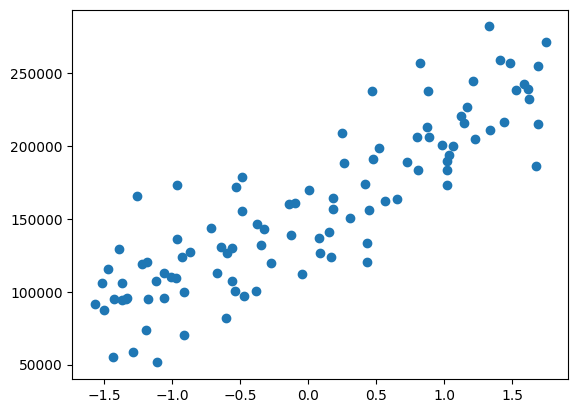

In [91]:
plt.scatter(X_scaled, Y)

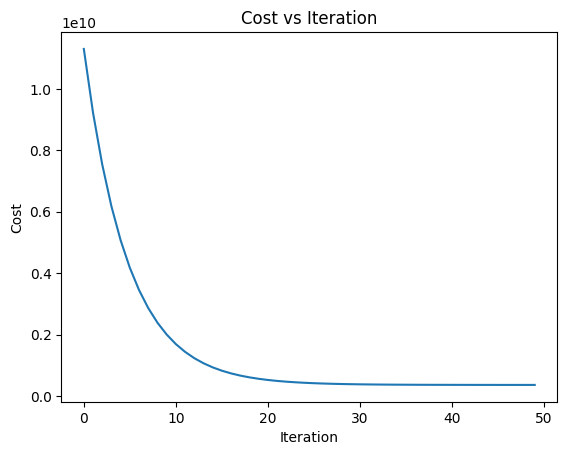

In [93]:
plt.plot(J_history)
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.title('Cost vs Iteration')
plt.show()

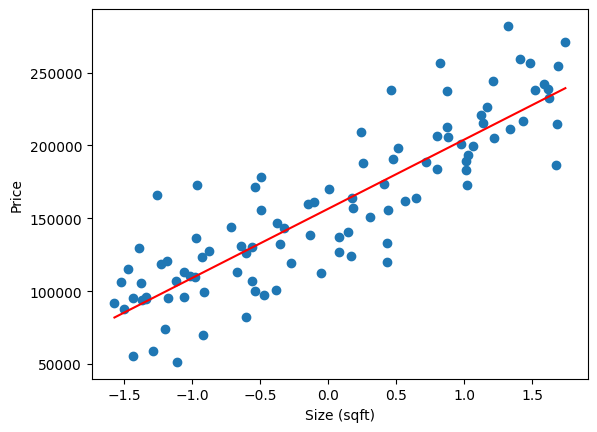

In [94]:
plt.scatter(X_scaled, Y)
plt.plot(X_scaled, w*X_scaled + b, color='red')
plt.xlabel('Size (sqft)')
plt.ylabel('Price')
plt.show()

In [95]:
print(J_history[-1])
print(f"w = {w}, b = {b}")

363312418.26287955
w = 47471.19835876609, b = 156438.79257013975


In [96]:
w_vals = np.linspace(0, 60000, 150)
b_vals = np.linspace(0, 220000, 150)
W,B=np.meshgrid(w_vals,b_vals)

Z=np.zeros(W.shape)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        Z[i,j]=computecost(X_scaled,Y,W[i,j],B[i,j],m)

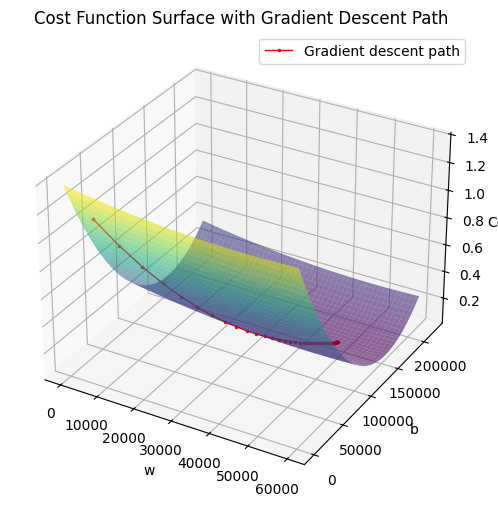

In [97]:
from mpl_toolkits.mplot3d import Axes3D
# Extract the path
w_history = [p[0] for p in p_history]
b_history = [p[1] for p in p_history]

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W, B, Z, cmap='viridis', alpha=0.6)

# Overlay the path - use J_history as the z-height at each point
ax.plot(w_history, b_history, J_history, color='red', marker='.', markersize=3, linewidth=1, label='Gradient descent path')

ax.set_xlabel('w')
ax.set_ylabel('b')
ax.set_zlabel('Cost')
ax.set_title('Cost Function Surface with Gradient Descent Path')
ax.legend()
plt.show()

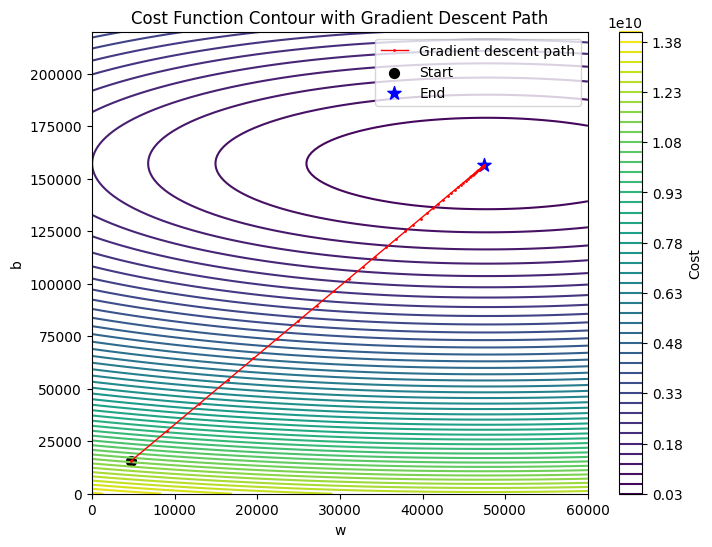

In [98]:
plt.figure(figsize=(8, 6))
plt.contour(W, B, Z, levels=50, cmap='viridis')
plt.xlabel('w') 
plt.ylabel('b')
plt.title('Cost Function Contour with Gradient Descent Path')
plt.colorbar(label='Cost')

# Overlay the path (top-down view doesn't need cost, just w and b)
plt.plot(w_history, b_history, color='red', marker='.', markersize=2, linewidth=1, label='Gradient descent path')
plt.scatter(w_history[0], b_history[0], color='black', marker='o', s=50, label='Start')
plt.scatter(w_history[-1], b_history[-1], color='blue', marker='*', s=100, label='End')

plt.legend()
plt.show()

Thank U

In [99]:
rmse = np.sqrt(2 * J_history[-1])
print("RMSE =", rmse)

RMSE = 26955.979606123743


In [100]:
%pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 286.1 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.2 MB 286.1 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.2 MB 286.1 kB/s eta 0:00:27
   -- ------------------------------------- 0.5/8.2 MB 286.1 kB/s eta 0:0

In [101]:
from sklearn.metrics import r2_score

y_pred = w * X_scaled + b
r2 = r2_score(Y, y_pred)

print("R² =", r2)

R² = 0.7580200910919752
